## This is a tutorial for GP regression form the GPyTorch documentation

In [1]:
import math
import torch
import gpytorch
from matplotlib import pyplot as plt
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../..")))

from deep_gp.gptorch_example import ExactGPModel
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
# Training data is 100 points in [0,1] inclusive regularly spaced
train_x = torch.linspace(0, 1, 100)
# True function is sin(2*pi*x) with Gaussian noise
train_y = torch.sin(train_x * (2 * math.pi)) + torch.randn(train_x.size()) * math.sqrt(0.04)

In [3]:
# initialize likelihood and model
likelihood = gpytorch.likelihoods.GaussianLikelihood()
model = ExactGPModel(train_x, train_y, likelihood)

In [4]:
# this is for running the notebook in our testing framework

smoke_test = ('CI' in os.environ)
training_iter = 2 if smoke_test else 50


# Find optimal model hyperparameters
model.train()   
likelihood.train()

# Use the adam optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.1)  # Includes GaussianLikelihood parameters

# "Loss" for GPs - the marginal log likelihood
mll = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, model)

for i in range(training_iter):
    # Zero gradients from previous iteration
    optimizer.zero_grad()
    # Output from model
    output = model(train_x)
    # Calc loss and backprop gradients
    loss = -mll(output, train_y)
    loss.backward()
    print('Iter %d/%d - Loss: %.3f   lengthscale: %.3f   noise: %.3f' % (
        i + 1, training_iter, loss.item(),
        model.covar_module.base_kernel.lengthscale.item(),
        model.likelihood.noise.item()
    ))
    optimizer.step()

Iter 1/50 - Loss: 0.953   lengthscale: 0.693   noise: 0.693
Iter 2/50 - Loss: 0.922   lengthscale: 0.644   noise: 0.644
Iter 3/50 - Loss: 0.888   lengthscale: 0.598   noise: 0.598
Iter 4/50 - Loss: 0.851   lengthscale: 0.555   noise: 0.554
Iter 5/50 - Loss: 0.809   lengthscale: 0.514   noise: 0.513
Iter 6/50 - Loss: 0.761   lengthscale: 0.475   noise: 0.474
Iter 7/50 - Loss: 0.710   lengthscale: 0.439   noise: 0.437
Iter 8/50 - Loss: 0.658   lengthscale: 0.404   noise: 0.402
Iter 9/50 - Loss: 0.608   lengthscale: 0.372   noise: 0.369
Iter 10/50 - Loss: 0.562   lengthscale: 0.342   noise: 0.339
Iter 11/50 - Loss: 0.521   lengthscale: 0.315   noise: 0.310
Iter 12/50 - Loss: 0.484   lengthscale: 0.291   noise: 0.284
Iter 13/50 - Loss: 0.449   lengthscale: 0.271   noise: 0.259
Iter 14/50 - Loss: 0.416   lengthscale: 0.254   noise: 0.236
Iter 15/50 - Loss: 0.384   lengthscale: 0.240   noise: 0.216
Iter 16/50 - Loss: 0.353   lengthscale: 0.229   noise: 0.196
Iter 17/50 - Loss: 0.322   length

In [5]:
# Get into evaluation (predictive posterior) mode
model.eval()
likelihood.eval()

# Test points are regularly spaced along [0,1]
# Make predictions by feeding model through likelihood
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_x = torch.linspace(0, 1, 51)
    observed_pred = likelihood(model(test_x))

In [6]:

f_preds = model(test_x)
y_preds = likelihood(model(test_x))

f_mean = f_preds.mean        
f_var = f_preds.variance
f_covar = f_preds.covariance_matrix
f_samples = f_preds.sample(sample_shape=torch.Size([1000]))

/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-06 to the diagonal
  warnings.warn(
/home/chrysoula/.cache/pypoetry/virtualenvs/deep-gp-BifO3guL-py3.11/lib/python3.11/site-packages/linear_operator/utils/cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-05 to the diagonal
  warnings.warn(


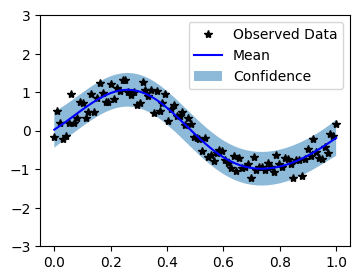

In [7]:
with torch.no_grad():  #Tells PyTorch not to compute gradients inside this block
    # Initialize plot
    f, ax = plt.subplots(1, 1, figsize=(4, 3))

    # Get upper and lower confidence bounds
    lower, upper = observed_pred.confidence_region()

    # Plot training data as black stars
    ax.plot(train_x.numpy(), train_y.numpy(), 'k*')  #.numpy() converts a PyTorch tensor into a NumPy array (a standard Python numerical array).
                                                   # This is necessary because matplotlib expects NumPy arrays for plotting.
    # Plot predictive means as blue line
    ax.plot(test_x.numpy(), observed_pred.mean.numpy(), 'b')
    # Shade between the lower and upper confidence bounds
    ax.fill_between(test_x.numpy(), lower.numpy(), upper.numpy(), alpha=0.5)
    ax.set_ylim([-3, 3])
    ax.legend(['Observed Data', 'Mean', 'Confidence'])